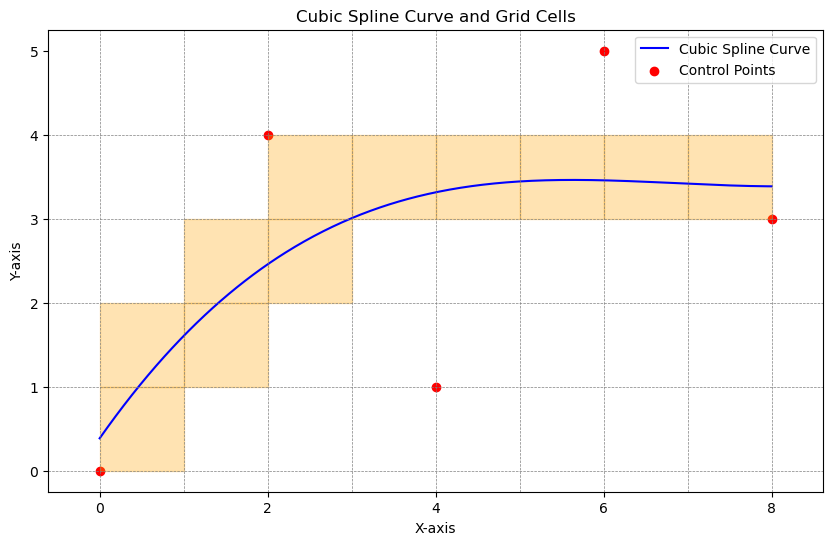

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Define the control points
control_points = np.array([[0, 0], [2, 4], [4, 1], [6, 5], [8, 3]])
x_points, y_points = control_points[:, 0], control_points[:, 1]

# Step 2: Generate a cubic spline using numpy.polyfit and polyval
n = len(x_points)
t = np.linspace(0, n - 1, 500)
spline_coeffs_x = np.polyfit(range(n), x_points, 3)  # Fit cubic for x
spline_coeffs_y = np.polyfit(range(n), y_points, 3)  # Fit cubic for y

spline_x = np.polyval(spline_coeffs_x, t)
spline_y = np.polyval(spline_coeffs_y, t)

# Step 3: Grid setup and check which cells are crossed
grid_size = 1  # Each grid cell is 1x1
x_min, x_max = int(np.floor(min(spline_x))), int(np.ceil(max(spline_x)))
y_min, y_max = int(np.floor(min(spline_y))), int(np.ceil(max(spline_y)))

grid_cells = set()
for x, y in zip(spline_x, spline_y):
    cell_x = int(np.floor(x / grid_size))
    cell_y = int(np.floor(y / grid_size))
    grid_cells.add((cell_x, cell_y))

# Step 4: Plot the spline curve and grid
plt.figure(figsize=(10, 6))
plt.plot(spline_x, spline_y, label="Cubic Spline Curve", color="blue")
plt.scatter(x_points, y_points, color="red", label="Control Points")

# Draw the grid
for x in range(x_min, x_max + 1):
    plt.axvline(x * grid_size, color="gray", linestyle="--", linewidth=0.5)
for y in range(y_min, y_max + 1):
    plt.axhline(y * grid_size, color="gray", linestyle="--", linewidth=0.5)

# Highlight cells the spline passes through
for cell_x, cell_y in grid_cells:
    plt.gca().add_patch(plt.Rectangle((cell_x * grid_size, cell_y * grid_size),
                                      grid_size, grid_size, color="orange", alpha=0.3))

plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Cubic Spline Curve and Grid Cells")
plt.axis("equal")
plt.show()


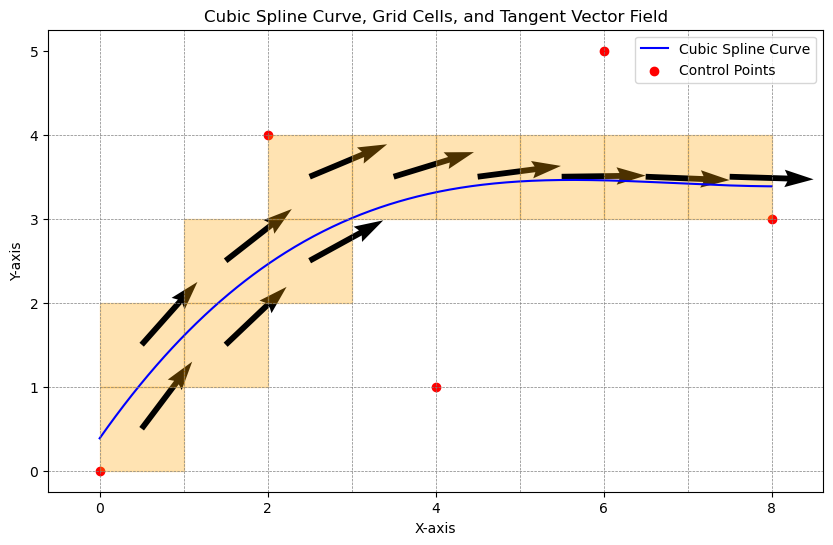

In [7]:
# Step 1: Compute tangents for the spline curve
# Derivatives of the spline
tangent_x = np.polyval(np.polyder(spline_coeffs_x), t)
tangent_y = np.polyval(np.polyder(spline_coeffs_y), t)

# Normalize the tangent vectors
tangent_magnitudes = np.sqrt(tangent_x**2 + tangent_y**2)
tangent_x /= tangent_magnitudes
tangent_y /= tangent_magnitudes

# Step 2: Compute the average tangent direction per grid cell
cell_tangents = {}
for i, (x, y) in enumerate(zip(spline_x, spline_y)):
    cell_x = int(np.floor(x / grid_size))
    cell_y = int(np.floor(y / grid_size))
    if (cell_x, cell_y) not in cell_tangents:
        cell_tangents[(cell_x, cell_y)] = []
    cell_tangents[(cell_x, cell_y)].append((tangent_x[i], tangent_y[i]))

# Average the tangents in each grid cell
average_tangents = {
    cell: np.mean(vectors, axis=0) for cell, vectors in cell_tangents.items()
}

# Normalize the averaged tangents
for cell in average_tangents:
    norm = np.linalg.norm(average_tangents[cell])
    if norm > 0:
        average_tangents[cell] /= norm

# Step 3: Plot the spline curve, grid, and vector field
plt.figure(figsize=(10, 6))
plt.plot(spline_x, spline_y, label="Cubic Spline Curve", color="blue")
plt.scatter(x_points, y_points, color="red", label="Control Points")

# Draw the grid
for x in range(x_min, x_max + 1):
    plt.axvline(x * grid_size, color="gray", linestyle="--", linewidth=0.5)
for y in range(y_min, y_max + 1):
    plt.axhline(y * grid_size, color="gray", linestyle="--", linewidth=0.5)

# Highlight cells the spline passes through and draw average tangent directions
for cell, tangent in average_tangents.items():
    cell_x, cell_y = cell
    plt.gca().add_patch(plt.Rectangle((cell_x * grid_size, cell_y * grid_size),
                                      grid_size, grid_size, color="orange", alpha=0.3))
    center_x = (cell_x + 0.5) * grid_size
    center_y = (cell_y + 0.5) * grid_size
    plt.quiver(center_x, center_y, tangent[0], tangent[1], angles="xy", scale_units="xy", scale=1, color="black")

plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Cubic Spline Curve, Grid Cells, and Tangent Vector Field")
plt.axis("equal")
plt.show()


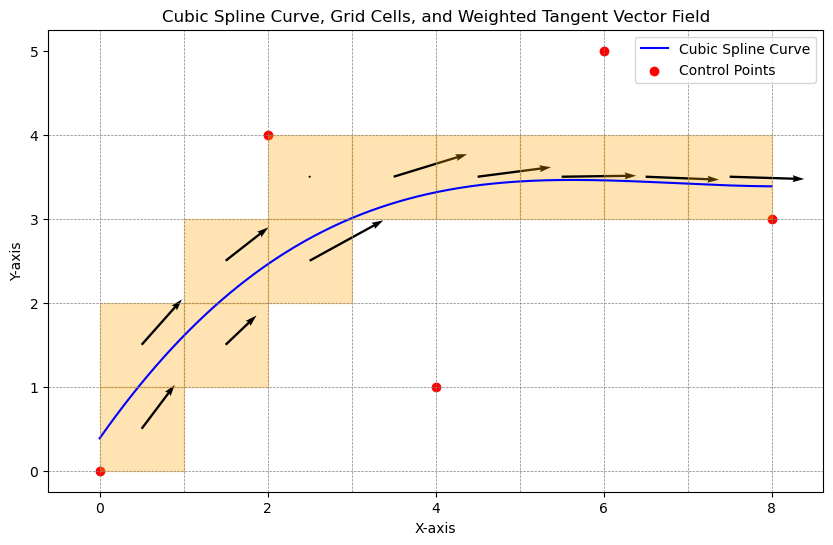

In [8]:
# Step 1: Compute the magnitude of the tangent vectors based on curve length within each cell
cell_tangents_magnitude = {cell: 0 for cell in cell_tangents}

for i, (x, y) in enumerate(zip(spline_x, spline_y)):
    cell_x = int(np.floor(x / grid_size))
    cell_y = int(np.floor(y / grid_size))
    if i > 0:
        dx = spline_x[i] - spline_x[i - 1]
        dy = spline_y[i] - spline_y[i - 1]
        segment_length = np.sqrt(dx**2 + dy**2)
        cell_tangents_magnitude[(cell_x, cell_y)] += segment_length

# Combine magnitude with average tangents
weighted_tangents = {
    cell: average_tangents[cell] * cell_tangents_magnitude[cell]
    for cell in average_tangents
}

# Normalize vectors for visualization, while retaining magnitude
max_magnitude = max(np.linalg.norm(v) for v in weighted_tangents.values())
normalized_tangents = {
    cell: (vector / max_magnitude) if np.linalg.norm(vector) > 0 else vector
    for cell, vector in weighted_tangents.items()
}

# Step 2: Plot the spline curve, grid, and updated vector field with magnitude
plt.figure(figsize=(10, 6))
plt.plot(spline_x, spline_y, label="Cubic Spline Curve", color="blue")
plt.scatter(x_points, y_points, color="red", label="Control Points")

# Draw the grid
for x in range(x_min, x_max + 1):
    plt.axvline(x * grid_size, color="gray", linestyle="--", linewidth=0.5)
for y in range(y_min, y_max + 1):
    plt.axhline(y * grid_size, color="gray", linestyle="--", linewidth=0.5)

# Highlight cells the spline passes through and draw weighted tangent directions
for cell, tangent in normalized_tangents.items():
    cell_x, cell_y = cell
    plt.gca().add_patch(plt.Rectangle((cell_x * grid_size, cell_y * grid_size),
                                      grid_size, grid_size, color="orange", alpha=0.3))
    center_x = (cell_x + 0.5) * grid_size
    center_y = (cell_y + 0.5) * grid_size
    plt.quiver(center_x, center_y, tangent[0], tangent[1], angles="xy", scale_units="xy", scale=1,
               color="black", width=0.003)

plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.title("Cubic Spline Curve, Grid Cells, and Weighted Tangent Vector Field")
plt.axis("equal")
plt.show()


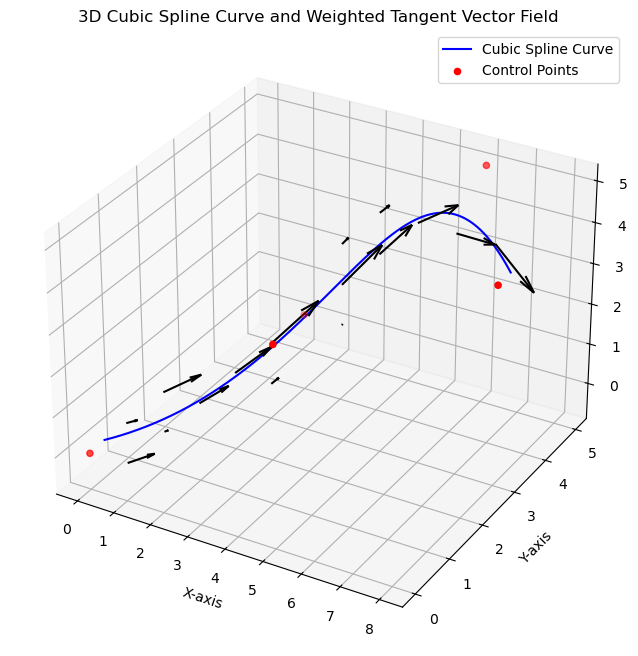

In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Step 1: Define control points for a 3D cubic spline
control_points_3d = np.array([[0, 0, 0], [2, 4, 1], [4, 1, 3], [6, 5, 5], [8, 3, 4]])
x_points_3d, y_points_3d, z_points_3d = control_points_3d[:, 0], control_points_3d[:, 1], control_points_3d[:, 2]

# Fit cubic splines for x, y, and z
spline_coeffs_x_3d = np.polyfit(range(len(x_points_3d)), x_points_3d, 3)
spline_coeffs_y_3d = np.polyfit(range(len(y_points_3d)), y_points_3d, 3)
spline_coeffs_z_3d = np.polyfit(range(len(z_points_3d)), z_points_3d, 3)

# Generate points along the spline
t_3d = np.linspace(0, len(x_points_3d) - 1, 500)
spline_x_3d = np.polyval(spline_coeffs_x_3d, t_3d)
spline_y_3d = np.polyval(spline_coeffs_y_3d, t_3d)
spline_z_3d = np.polyval(spline_coeffs_z_3d, t_3d)

# Step 2: Compute grid cells the curve passes through
grid_size_3d = 1  # Each grid cell is 1x1x1
x_min_3d, x_max_3d = int(np.floor(min(spline_x_3d))), int(np.ceil(max(spline_x_3d)))
y_min_3d, y_max_3d = int(np.floor(min(spline_y_3d))), int(np.ceil(max(spline_y_3d)))
z_min_3d, z_max_3d = int(np.floor(min(spline_z_3d))), int(np.ceil(max(spline_z_3d)))

grid_cells_3d = set()
for x, y, z in zip(spline_x_3d, spline_y_3d, spline_z_3d):
    cell_x = int(np.floor(x / grid_size_3d))
    cell_y = int(np.floor(y / grid_size_3d))
    cell_z = int(np.floor(z / grid_size_3d))
    grid_cells_3d.add((cell_x, cell_y, cell_z))

# Step 3: Compute tangent vectors and their magnitudes
tangent_x_3d = np.polyval(np.polyder(spline_coeffs_x_3d), t_3d)
tangent_y_3d = np.polyval(np.polyder(spline_coeffs_y_3d), t_3d)
tangent_z_3d = np.polyval(np.polyder(spline_coeffs_z_3d), t_3d)

# Normalize tangent vectors
tangent_magnitudes_3d = np.sqrt(tangent_x_3d**2 + tangent_y_3d**2 + tangent_z_3d**2)
tangent_x_3d /= tangent_magnitudes_3d
tangent_y_3d /= tangent_magnitudes_3d
tangent_z_3d /= tangent_magnitudes_3d

# Accumulate tangents and magnitudes for each grid cell
cell_tangents_3d = {cell: [] for cell in grid_cells_3d}
cell_magnitudes_3d = {cell: 0 for cell in grid_cells_3d}

for i, (x, y, z) in enumerate(zip(spline_x_3d, spline_y_3d, spline_z_3d)):
    cell_x = int(np.floor(x / grid_size_3d))
    cell_y = int(np.floor(y / grid_size_3d))
    cell_z = int(np.floor(z / grid_size_3d))
    cell = (cell_x, cell_y, cell_z)
    cell_tangents_3d[cell].append((tangent_x_3d[i], tangent_y_3d[i], tangent_z_3d[i]))
    if i > 0:
        dx, dy, dz = spline_x_3d[i] - spline_x_3d[i - 1], spline_y_3d[i] - spline_y_3d[i - 1], spline_z_3d[i] - spline_z_3d[i - 1]
        cell_magnitudes_3d[cell] += np.sqrt(dx**2 + dy**2 + dz**2)

# Average tangents and apply magnitude scaling
average_tangents_3d = {}
for cell, vectors in cell_tangents_3d.items():
    avg_tangent = np.mean(vectors, axis=0)
    norm = np.linalg.norm(avg_tangent)
    if norm > 0:
        avg_tangent /= norm
    avg_tangent *= cell_magnitudes_3d[cell]  # Scale by curve length in the cell
    average_tangents_3d[cell] = avg_tangent

# Step 4: Plot the spline curve and the 3D vector field
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the spline curve
ax.plot(spline_x_3d, spline_y_3d, spline_z_3d, label="Cubic Spline Curve", color="blue")
ax.scatter(x_points_3d, y_points_3d, z_points_3d, color="red", label="Control Points")

# Draw the vector field
for cell, tangent in average_tangents_3d.items():
    cell_x, cell_y, cell_z = cell
    center_x = (cell_x + 0.5) * grid_size_3d
    center_y = (cell_y + 0.5) * grid_size_3d
    center_z = (cell_z + 0.5) * grid_size_3d
    ax.quiver(center_x, center_y, center_z, tangent[0], tangent[1], tangent[2],
              length=1, normalize=False, color="black")

# Set labels and show the plot
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
ax.set_title("3D Cubic Spline Curve and Weighted Tangent Vector Field")
ax.legend()
plt.show()


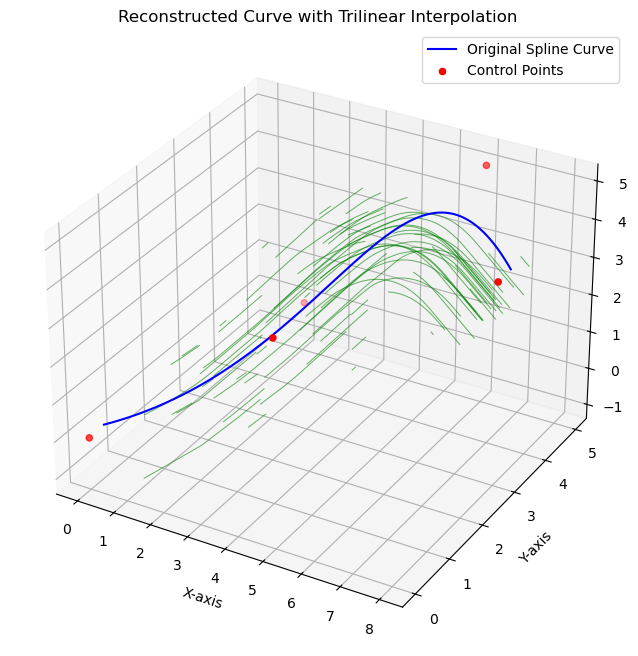

In [17]:
def trilinear_interpolation(position, vector_field, grid_size):
    """
    Perform trilinear interpolation of the vector field at a given position.

    Parameters:
        position (tuple): The (x, y, z) position in the grid.
        vector_field (dict): Dictionary of cell -> velocity vector.
        grid_size (float): The size of the grid cells.

    Returns:
        np.array: Interpolated velocity vector.
    """
    x, y, z = position
    # Calculate the cell indices
    cell_x = int(np.floor(x / grid_size))
    cell_y = int(np.floor(y / grid_size))
    cell_z = int(np.floor(z / grid_size))

    # Compute fractional offsets within the voxel
    fx = (x / grid_size) - cell_x
    fy = (y / grid_size) - cell_y
    fz = (z / grid_size) - cell_z

    # Initialize interpolated velocity
    velocity = np.zeros(3)

    # Perform trilinear interpolation
    for dx in [0, 1]:
        for dy in [0, 1]:
            for dz in [0, 1]:
                corner_cell = (cell_x + dx, cell_y + dy, cell_z + dz)
                weight = (1 - fx if dx == 0 else fx) * \
                         (1 - fy if dy == 0 else fy) * \
                         (1 - fz if dz == 0 else fz)
                if corner_cell in vector_field:
                    velocity += weight * np.array(vector_field[corner_cell])

    return velocity

def smooth_vector_field(vector_field, sigma=1):
    """
    Apply Gaussian smoothing to the vector field.

    Parameters:
        vector_field (dict): Dictionary of cell -> velocity vector.
        sigma (float): Standard deviation for Gaussian kernel.

    Returns:
        dict: Smoothed vector field.
    """
    # Extract the grid dimensions
    keys = np.array(list(vector_field.keys()))
    values = np.array(list(vector_field.values()))

    # Determine the shape of the grid
    grid_shape = keys.max(axis=0) + 1

    # Create an empty grid for each velocity component
    vx = np.zeros(grid_shape)
    vy = np.zeros(grid_shape)
    vz = np.zeros(grid_shape)

    # Populate the grids with the vector field values
    for (i, j, k), (vx_val, vy_val, vz_val) in zip(keys, values):
        vx[i, j, k] = vx_val
        vy[i, j, k] = vy_val
        vz[i, j, k] = vz_val
    from scipy.ndimage import gaussian_filter
    # Apply Gaussian smoothing
    vx_smooth = gaussian_filter(vx, sigma=sigma)
    vy_smooth = gaussian_filter(vy, sigma=sigma)
    vz_smooth = gaussian_filter(vz, sigma=sigma)

    # Create the smoothed vector field dictionary
    smoothed_vector_field = {}
    for (i, j, k) in keys:
        smoothed_vector_field[(i, j, k)] = (vx_smooth[i, j, k], vy_smooth[i, j, k], vz_smooth[i, j, k])

    return smoothed_vector_field

# Smooth the vector field
smoothed_vector_field = smooth_vector_field(average_tangents_3d, sigma=1)


def reconstruct_curve_trilinear(vector_field, grid_size, bounds, num_points=100):
    """
    Reconstruct the curve using trilinear interpolation of the vector field.

    Parameters:
        vector_field (dict): Dictionary of cell -> velocity vector.
        grid_size (float): The size of the grid cells.
        bounds (tuple): (x_min, x_max, y_min, y_max, z_min, z_max) bounds of the grid.
        num_points (int): Number of random starting points.

    Returns:
        list: A list of reconstructed paths.
    """
    x_min, x_max, y_min, y_max, z_min, z_max = bounds
    paths = []

    for _ in range(num_points):
        # Start at a random point within the bounds
        x = np.random.uniform(x_min, x_max)
        y = np.random.uniform(y_min, y_max)
        z = np.random.uniform(z_min, z_max)
        path = [(x, y, z)]

        while True:
            # Interpolate the velocity at the current position
            velocity = trilinear_interpolation((x, y, z), vector_field, grid_size)
            if np.linalg.norm(velocity) > 1e-6:  # Non-zero velocity
                # Update position based on the interpolated velocity
                x += velocity[0] * grid_size * 0.01  # Scale step size
                y += velocity[1] * grid_size * 0.01
                z += velocity[2] * grid_size * 0.01
                path.append((x, y, z))

                # Check if the point moves outside the grid bounds
                if not (x_min <= x <= x_max and y_min <= y <= y_max and z_min <= z <= z_max):
                    break
            else:
                break  # Stop if velocity is zero

        paths.append(np.array(path))

    return paths


# Reconstruct curve using trilinear interpolation
reconstructed_paths_trilinear = reconstruct_curve_trilinear(
    average_tangents_3d, grid_size_3d, bounds_3d, num_points=200
)

# Plotting the reconstructed paths with trilinear interpolation
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot reconstructed paths
for path in reconstructed_paths_trilinear:
    ax.plot(path[:, 0], path[:, 1], path[:, 2], color="green", alpha=0.6, linewidth=0.7)

# Overlay original spline curve
ax.plot(spline_x_3d, spline_y_3d, spline_z_3d, label="Original Spline Curve", color="blue")
ax.scatter(x_points_3d, y_points_3d, z_points_3d, color="red", label="Control Points")

# Set labels and show plot
ax.set_xlabel("X-axis")
ax.set_ylabel("Y-axis")
ax.set_zlabel("Z-axis")
ax.set_title("Reconstructed Curve with Trilinear Interpolation")
ax.legend()
plt.show()


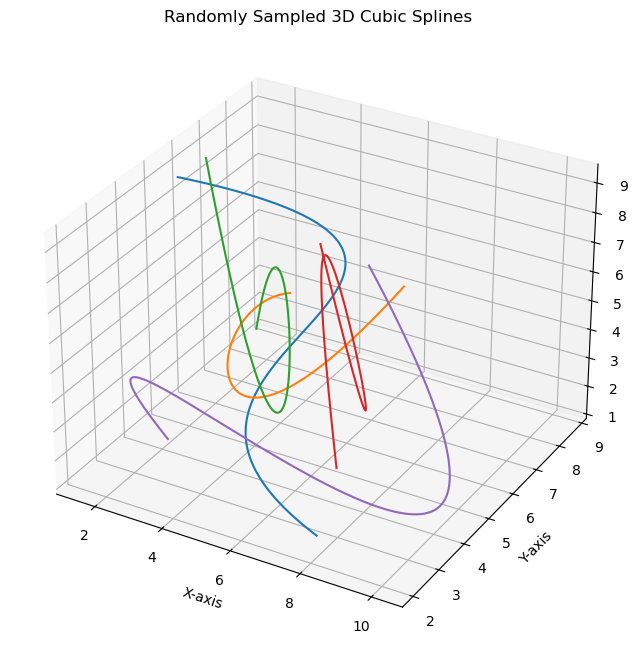

In [79]:
%reload_ext autoreload
%autoreload 2

In [80]:
from dmri.simulators.global_signal_models.curves3d import sample_splines, VoxelGrid, get_average_tangent_in_voxels, get_spline_volume_fraction_in_voxels
import jax
import jax.numpy as jnp

import matplotlib.pyplot as plt

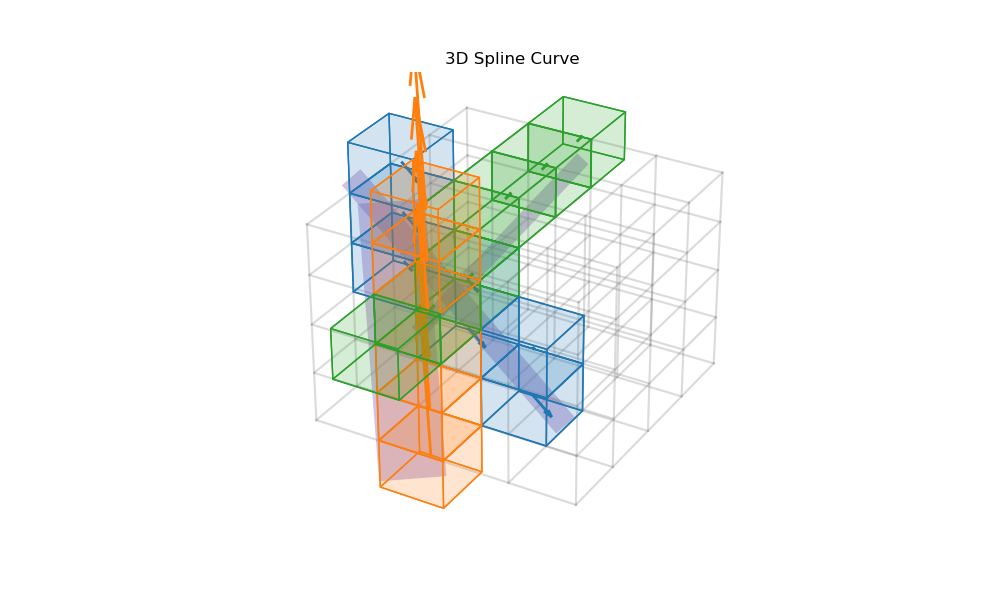

In [160]:
%matplotlib widget

from itertools import combinations, product
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
grid = VoxelGrid(4,4,4)
ax.grid(False)

grid_lines_x, grid_lines_y, grid_lines_z = grid.get_grid_lines()


start = 13
for i in range(3):
    diameter = jax.random.uniform(jax.random.key(start +100 + i), shape=(), minval=0.05, maxval=0.4)
    spline = sample_splines(jax.random.key(start + i), degree=1)
    t_line = jnp.linspace(0, 1, 100)
    spline_values = spline(t_line)
    voxel_idxs = jax.vmap(grid.get_voxel_index_for_point)(spline_values)
    voxel_idxs = jnp.unique(voxel_idxs, axis=0)

    average_tangets = get_average_tangent_in_voxels(spline, grid)
    volume_fraction = get_spline_volume_fraction_in_voxels(spline, grid,diameter)


    for voxel_idx in voxel_idxs:
        voxel_start, voxel_end = grid.get_voxel_boundaries(*voxel_idx)
        # Create a list of vertices for the 3D box
        vertices = [
            [voxel_start[0], voxel_start[1], voxel_start[2]],
            [voxel_start[0], voxel_start[1], voxel_end[2]],
            [voxel_start[0], voxel_end[1], voxel_start[2]],
            [voxel_start[0], voxel_end[1], voxel_end[2]],
            [voxel_end[0], voxel_start[1], voxel_start[2]],
            [voxel_end[0], voxel_start[1], voxel_end[2]],
            [voxel_end[0], voxel_end[1], voxel_start[2]],
            [voxel_end[0], voxel_end[1], voxel_end[2]]
        ]

        # Create a list of sides for the 3D box
        sides = [[vertices[j] for j in [0, 1, 3, 2]],
                 [vertices[j] for j in [4, 5, 7, 6]],
                 [vertices[j] for j in [0, 1, 5, 4]],
                 [vertices[j] for j in [2, 3, 7, 6]],
                 [vertices[j] for j in [0, 2, 6, 4]],
                 [vertices[j] for j in [1, 3, 7, 5]]]

        # Add the 3D box to the plot
        ax.add_collection3d(Poly3DCollection(sides, facecolors=f'C{i}', linewidths=1, edgecolors=f'C{i}', alpha=.1))

    # Plot the average tangent vectors
    for voxel_idx in voxel_idxs:
        avg_tangent = average_tangets[tuple(voxel_idx)]
        center = jnp.array(grid.get_voxel_center(*voxel_idx))
        volume = volume_fraction[tuple(voxel_idx)]
        norm = jnp.linalg.norm(avg_tangent)
        if norm > 0:
            # Calculate the endpoint to maintain the direction
            direction = avg_tangent / norm #* 0.25  # Normalize the tangent

            ax.quiver(center[0], center[1], center[2], direction[0],direction[1],direction[2], color=f'C{i}', length=volume, lw=2)

    # Plot the grid lines
    for i in range(grid_lines_x.shape[0]):
        for j in range(grid_lines_x.shape[1]):
            ax.plot(grid_lines_x[i, j, :], grid_lines_y[i, j, :], grid_lines_z[i, j, :], color='gray', alpha=0.1)
            ax.plot(grid_lines_x[i, :, j], grid_lines_y[i, :, j], grid_lines_z[i, :, j], color='gray', alpha=0.1)
            ax.plot(grid_lines_x[:, i, j], grid_lines_y[:, i, j], grid_lines_z[:, i, j], color='gray', alpha=0.1)


    # Plot the spline values
    ax.plot(spline_values[:, 0], spline_values[:, 1], spline_values[:, 2], lw=diameter*200, alpha=0.4, color=f'C{i}')


    # Set labels and show plot
    # ax.set_xlabel("X-axis")
    # ax.set_ylabel("Y-axis")
    # ax.set_zlabel("Z-axis")
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(0, 1)
    ax.set_title("3D Spline Curve")

plt.show()

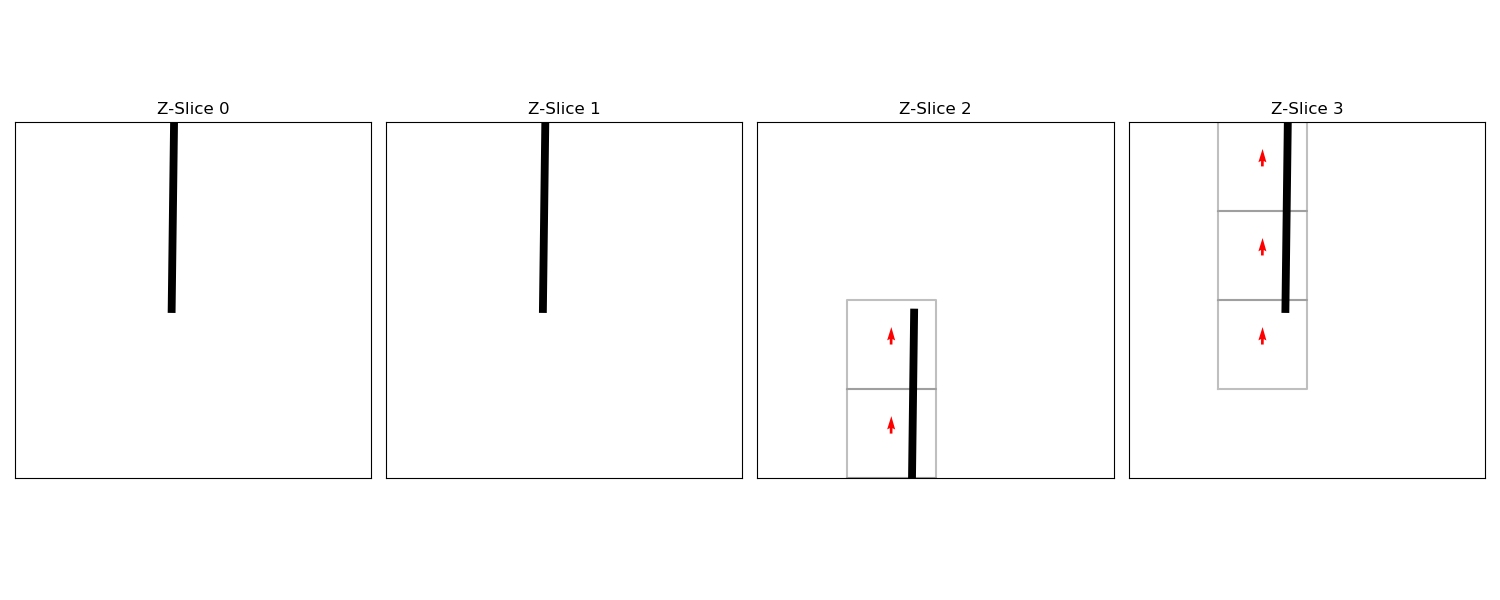

In [157]:

# Assuming VoxelGrid and required functions are defined

fig, axs = plt.subplots(1, grid.n_voxels_z, figsize=(15, 6))

# Iterate over all Z-slices
for z in range(grid.n_voxels_z):
    ax = axs[z]
    ax.set_title(f"Z-Slice {z}")

    # Extract the voxel boundaries and data for this slice
    for voxel_idx in voxel_idxs:
        if voxel_idx[2] == z:  # Only process voxels in the current Z-slice
            voxel_start, voxel_end = grid.get_voxel_boundaries(*voxel_idx)

            # Define the rectangle's corners for 2D representation
            rect_x = [voxel_start[0], voxel_end[0], voxel_end[0], voxel_start[0], voxel_start[0]]
            rect_y = [voxel_start[1], voxel_start[1], voxel_end[1], voxel_end[1], voxel_start[1]]

            # Plot the voxel as a 2D rectangle
            ax.plot(rect_x, rect_y, color='gray', alpha=0.5)

            # Plot the tangent vector for the voxel
            avg_tangent = average_tangets[tuple(voxel_idx)]
            center = jnp.array(grid.get_voxel_center(*voxel_idx))

            # Normalize tangent for proper scaling
            norm = jnp.linalg.norm(avg_tangent)
            if norm > 0:
                direction = avg_tangent[:2] / norm * 0.05  # Normalize for 2D visualization
                ax.quiver(center[0], center[1], direction[0], direction[1], color='red', scale=1, scale_units='xy', angles='xy')

    # Filter and plot spline segments within this Z slice
    spline_mask = (spline_values[:, 2] >= voxel_start[2]) & (spline_values[:, 2] < voxel_end[2])
    valid_spline_points = spline_values[spline_mask]

    if len(valid_spline_points) > 1:
        ax.plot(valid_spline_points[:, 0], valid_spline_points[:, 1], lw=diameter*100, color='black')

    # Set plot limits and formatting
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()


In [120]:
from dmri.utils.transform import normal_to_dirichlet, dirichlet_to_normal
import jax
import jax.numpy as jnp

alpha = jnp.array([1.,1.,1.])
mask = jnp.array([True, True, False])

eps = jax.random.normal(jax.random.key(0), shape=(2,))

In [5]:
pi = normal_to_dirichlet(alpha, eps, mask)
pi

Array([0.17340326, 0.71186775, 0.        ], dtype=float32, weak_type=True)

In [6]:
eps = dirichlet_to_normal(alpha,pi, mask)
eps

Array([-0.9408017,  0.       ], dtype=float32)